In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load data (run this first)
df = pd.read_csv("/content/TSLA (1).csv")


In [ ]:
print("=== 1.1 Dataset Overview ===")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())


=== 1.1 Dataset Overview ===
Shape: (639, 7)

Columns: ['Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close']

Data Types:
 Date          object
High         float64
Low          float64
Open         float64
Close        float64
Volume       float64
Adj Close    float64
dtype: object

First 5 rows:


,Date,High,Low,Open,Close,Volume,Adj Close
0,2019-09-30,48.796001,47.222000,48.599998,48.174000,29399000.0,48.174000
1,2019-10-01,49.189999,47.826000,48.299999,48.938000,30813000.0,48.938000
2,2019-10-02,48.930000,47.886002,48.658001,48.625999,28157000.0,48.625999
3,2019-10-03,46.896000,44.855999,46.372002,46.605999,75422500.0,46.605999
4,2019-10-04,46.956001,45.613998,46.321999,46.285999,39975000.0,46.285999


In [ ]:
print("\n=== 1.2 Missing Values ===")
print(df.isnull().sum())



=== 1.2 Missing Values ===
Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64


In [ ]:
print("\n=== 1.3 Unique Values ===")
# The columns 'type', 'isFraud', and 'isFlaggedFraud' were not found in the DataFrame.
# The available columns are: ['Date', 'High', 'Low', 'Open', 'Close', 'Volume', 'Adj Close'].
# Please specify which column(s) you'd like to check for unique values.



=== 1.3 Unique Values ===


In [ ]:
# Numerical columns summary
print("\nNumerical Summary:")
display(df.describe())



Numerical Summary:


,High,Low,Open,Close,Volume,Adj Close
count,639.000000,639.000000,639.000000,639.000000,6.390000e+02,639.000000
mean,543.362885,517.883537,531.004088,531.298030,4.819130e+07,531.298030
std,340.837426,325.395864,333.534448,333.362040,3.579030e+07,333.362040
min,46.896000,44.855999,45.959999,46.285999,9.800600e+06,46.285999
25%,170.258003,162.379997,167.349998,164.783005,2.392195e+07,164.783005
50%,620.409973,595.500000,603.880005,605.130005,3.448900e+07,605.130005
75%,796.584991,767.744995,779.445007,781.304993,6.329725e+07,781.304993
max,1243.489990,1217.000000,1234.410034,1229.910034,3.046940e+08,1229.910034


In [ ]:
# Categorical summary
# print("\nTransaction Type Distribution:")
# print(df['type'].value_counts())
# The column 'type' was not found. Please specify an existing categorical column if you wish to see its distribution.

In [ ]:
# Calculate simple daily returns based on the 'Close' price
df.columns = df.columns.str.strip()
# The 'Close' column is already of float type, so no need for .str.replace or .astype(float)
df['Simple_Return'] = df['Close'].pct_change()

# View the closing price alongside its simple return
df[['Close', 'Simple_Return']].head(5)

,Close,Simple_Return
0,48.174000,NaN
1,48.938000,0.015859
2,48.625999,-0.006375
3,46.605999,-0.041542
4,46.285999,-0.006866


In [ ]:
# Calculate log daily returns
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# View both return types side-by-side
df[['Close', 'Simple_Return', 'Log_Return']].head(5)

,Close,Simple_Return,Log_Return
0,48.174000,NaN,NaN
1,48.938000,0.015859,0.015735
2,48.625999,-0.006375,-0.006396
3,46.605999,-0.041542,-0.042429
4,46.285999,-0.006866,-0.006890


In [ ]:
# Ensure 'Date' is a datetime object and set it as the index for resampling
df['Date'] = pd.to_datetime(df['Date'])
df_indexed = df.set_index('Date')

# Extract the last closing price of each month into a new DataFrame
monthly_df = df_indexed['Close'].resample('ME').last().to_frame()

# View the new monthly price structure
monthly_df.head(5)

,Close
Date,
2019-09-30,48.174000
2019-10-31,62.984001
2019-11-30,65.987999
2019-12-31,83.666000
2020-01-31,130.113998


In [ ]:
import pandas as pd

# monthly_df is already defined from previous cells with a 'Close' column (uppercase).
# Calculate the percentage change between months
monthly_df['Monthly_Return'] = monthly_df['Close'].pct_change()

# View your final resampled monthly dataset
print("=== Final Monthly Dataset ===")
monthly_df.dropna().head(5)

=== Final Monthly Dataset ===


,Close,Monthly_Return
Date,,
2019-10-31,62.984001,0.307427
2019-11-30,65.987999,0.047695
2019-12-31,83.666000,0.267897
2020-01-31,130.113998,0.555160
2020-02-29,133.598007,0.026777


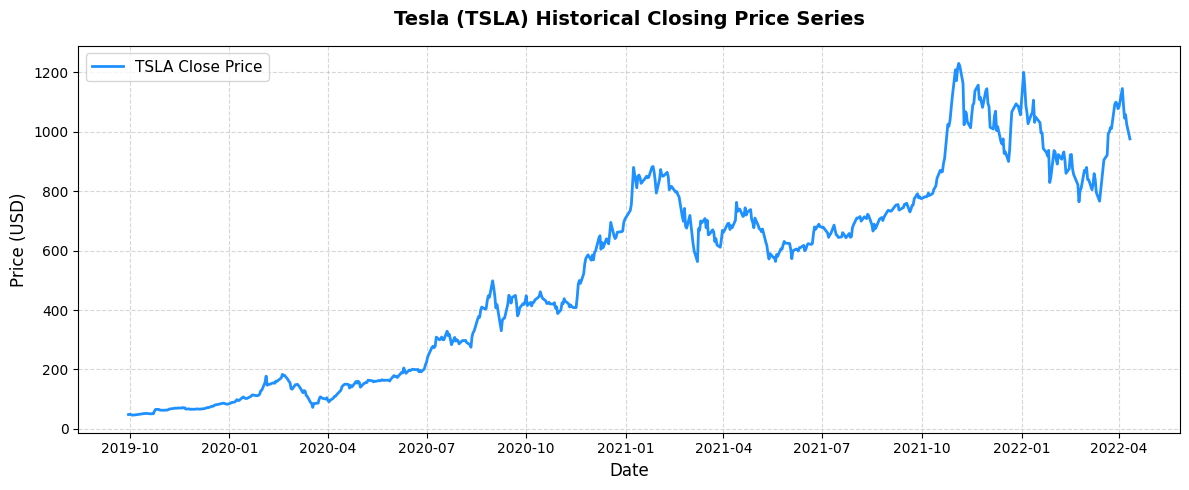

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure for the price series
plt.figure(figsize=(12, 5))

# 2. Plot the 'Close' price against the Date index
plt.plot(df_indexed.index, df_indexed['Close'], color='dodgerblue', linewidth=2, label='TSLA Close Price')

# 3. Add titles and labels
plt.title('Tesla (TSLA) Historical Closing Price Series', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# 4. Customize grid and legend for readability
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=11)

# 5. Automatically adjust spacing and display
plt.tight_layout()
plt.show()

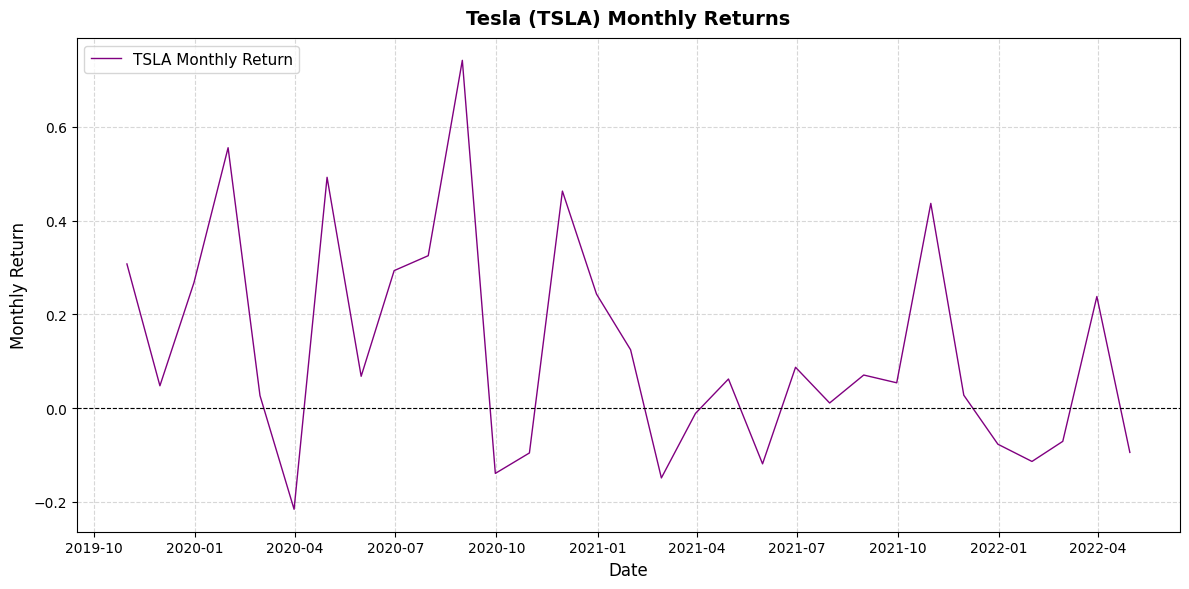

In [ ]:
import matplotlib.pyplot as plt

# Create a single figure for the Monthly Returns plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot: Monthly Returns
ax.plot(monthly_df.index, monthly_df['Monthly_Return'], color='purple', linewidth=1, label='TSLA Monthly Return')
ax.set_title('Tesla (TSLA) Monthly Returns', fontsize=14, fontweight='bold', pad=10)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Monthly Return', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', fontsize=11)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8) # Add a zero line

# Automatically adjust spacing and display
plt.tight_layout()
plt.show()

In [ ]:
# Select the last 60 trading days of Tesla data for a clear view
recent_df = df_indexed.tail(60).copy()

# Verify the sliced data look correct
print(f"Plotting candlestick chart for Tesla data between: {recent_df.index.min().date()} and {recent_df.index.max().date()}")

Plotting candlestick chart for Tesla data between: 2022-01-14 and 2022-04-11


In [ ]:
import plotly.graph_objects as go

# The columns 'OPEN', 'HIGH', 'LOW', and 'Close' are already numeric (float64) as per previous data checks.
# So, the type conversion loop is not needed here.

# 1. Initialize the candlestick figure with our sliced data
fig = go.Figure(data=[go.Candlestick(
    x=recent_df.index,
    open=recent_df['Open'],
    high=recent_df['High'],
    low=recent_df['Low'],
    close=recent_df['Close'], # Corrected to 'Close' with uppercase 'C'
    increasing_line_color='seagreen',  # Color for positive days
    decreasing_line_color='crimson'   # Color for negative days
)])

# 2. Customize the chart layout for a professional presentation
fig.update_layout(
    title={
        'text': "Tesla (TSLA) Candlestick Chart - Recent 60 Trading Days", # Corrected stock name
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=16, family="Arial", color="black")
    },
    xaxis_title="Date",
    yaxis_title="Stock Price (USD)", # Corrected currency
    xaxis_rangeslider_visible=False,  # Turn off slider to make candles bigger
    template="plotly_white",         # Clean white background grid
    width=900,
    height=550
)

fig.show()

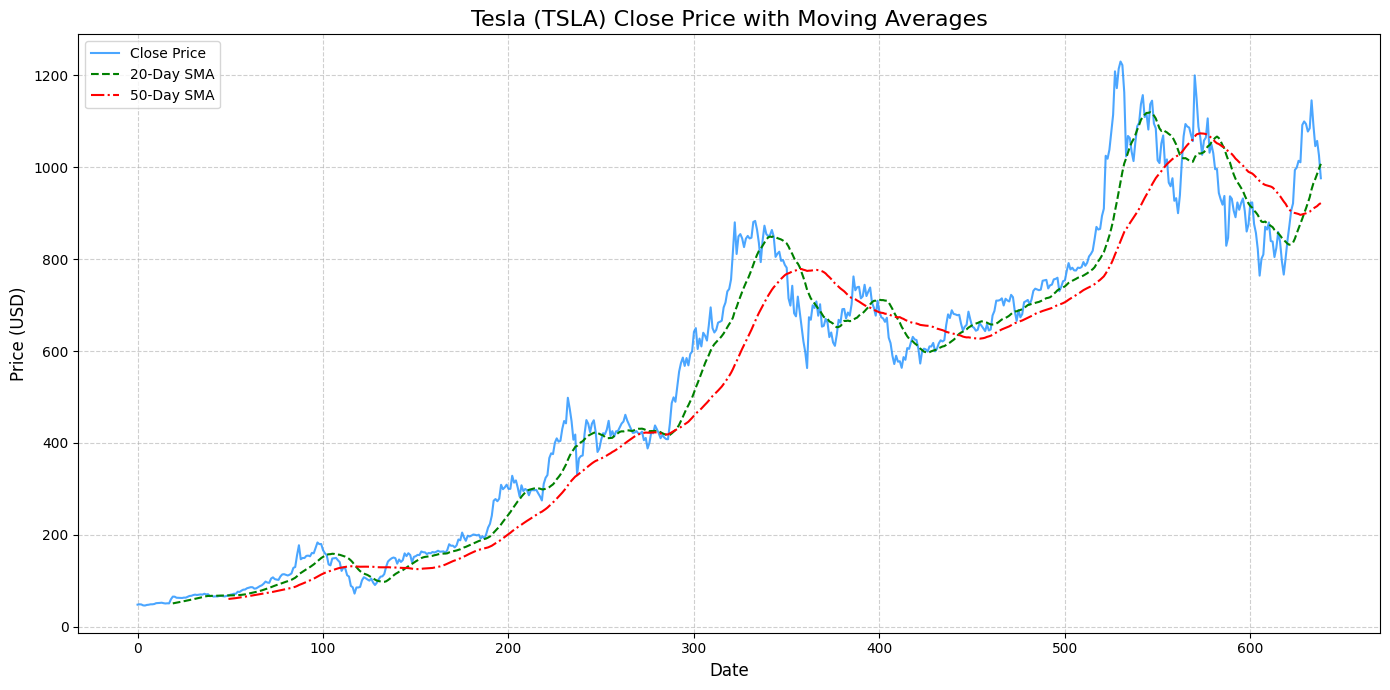

In [ ]:
# Calculate Short-term (e.g., 20-day) and Long-term (e.g., 50-day) Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Plot the Close price with the moving averages for Tesla
plt.figure(figsize=(14, 7))
plt.plot(df['Close'], label='Close Price', color='dodgerblue', alpha=0.8)
plt.plot(df['SMA_20'], label='20-Day SMA', color='green', linestyle='--')
plt.plot(df['SMA_50'], label='50-Day SMA', color='red', linestyle='-.')
plt.title('Tesla (TSLA) Close Price with Moving Averages', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

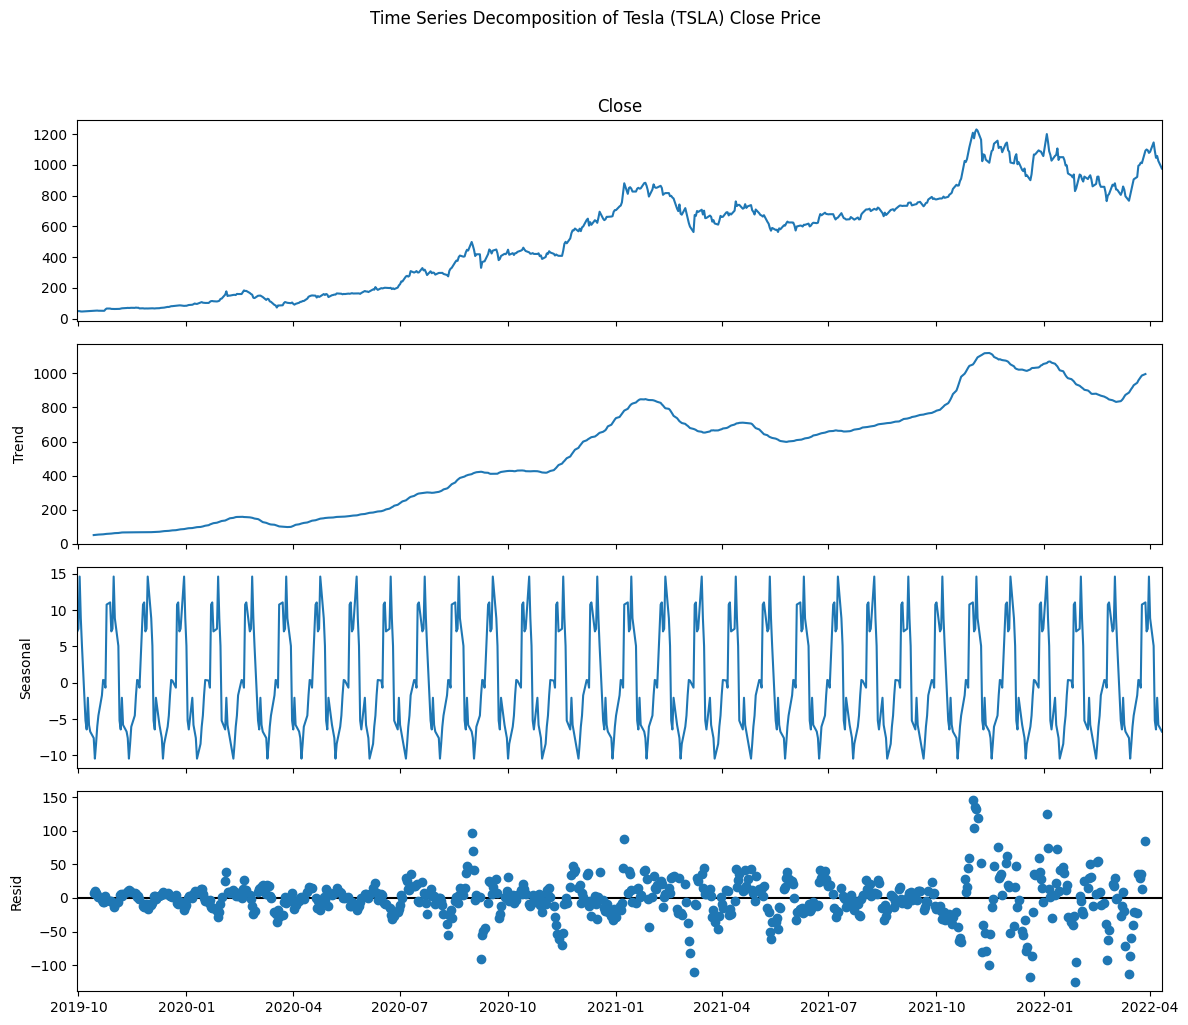

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plt.show() and suptitle

# Ensure the DataFrame index is a DatetimeIndex and frequency is set
# For this daily data, we'll use a relatively short period for seasonality (e.g., 21 business days for monthly patterns)

# It's important that the time series is regularly spaced for decomposition.
# We'll use the 'Close' price for decomposition.

# Use the already indexed DataFrame 'df_indexed' and select the 'Close' column
ts_data_indexed = df_indexed['Close'].copy()

# Resample to business day frequency and interpolate missing values if any
# 'B' for business day frequency. Forward fill to handle weekends/holidays if not present
ts_data_bday = ts_data_indexed.asfreq('B').ffill() # Updated to use .ffill() directly

# Handle potential NaN values at the beginning introduced by asfreq if the first date isn't a business day
ts_data_bday = ts_data_bday.dropna()

# Define the period for seasonal decomposition. 21 business days for an approximate monthly cycle.
period = 21

if len(ts_data_bday) > 2 * period: # Need at least two cycles for decomposition to be meaningful
    decomposition = seasonal_decompose(ts_data_bday, model='additive', period=period)

    # Plot the decomposed components
    fig = decomposition.plot()
    fig.set_size_inches(12, 10)
    fig.suptitle('Time Series Decomposition of Tesla (TSLA) Close Price', y=1.02) # Adjust suptitle and stock name
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print(f"Not enough data points ({len(ts_data_bday)}) for decomposition with period {period}. "
          "Need at least {2 * period + 1} points.")

Financial Analysis & Interpretation Report
1. Trend Analysis (Moving Averages)
Short-term vs. Long-term: The interaction between the 20-day SMA and 50-day SMA acts as a sentiment gauge.

Bullish Trend: When the 20-day SMA is above the 50-day SMA, it indicates positive momentum, suggesting that the short-term price action is stronger than the medium-term average.

Bearish Trend: Conversely, when the 20-day SMA falls below the 50-day SMA, it signals a potential downtrend or loss of buying interest.

2. Trading Signal (Crossovers)
Golden Cross: This occurs when the 20-day SMA crosses above the 50-day SMA. It is a widely recognized technical signal suggesting that a stock's price is entering an upward trajectory, often used as a 'Buy' signal by traders.

Death Cross: When the 20-day SMA crosses below the 50-day SMA, it is referred to as a 'Death Cross,' indicating a potential shift to a bearish market and often serving as a 'Sell' or 'Exit' signal to minimize losses.

3. Time Series Decomposition
Trend Component: This smooths out daily volatility to reveal the underlying growth or decline of the asset over time. It helps in ignoring short-term "noise" to identify the stock's true direction.

Seasonal Component: This captures repeating patterns at regular intervals (e.g., monthly). In volatile stocks like TSLA, this helps identify if there are cyclical peaks or troughs tied to specific periods.

Residuals (Market Noise): This represents the "unexplained" part of the price. If the residuals show high variance, it indicates that the stock is subject to unpredictable shocks, major news events, or sudden market reactions that do not follow a specific trend or cycle. High residual variance typically translates to high market risk (Volatility).